29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8220 - loss: 0.4959 - val_accuracy: 0.8728 - val_loss: 0.3631
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8792 - loss: 0.3348 - val_accuracy: 0.8918 - val_loss: 0.3072
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8971 - loss: 0.2820 - val_accuracy: 0.8977 - val_loss: 0.2871
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9088 - loss: 0.2488 - val_accuracy: 0.9052 - val_loss: 0.2634
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9164 - loss: 0.2263 - val_accuracy: 0.9037 - val_loss: 0.2634
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9000 - loss: 0.2789

Test Accuracy: 0.8999999761581421
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


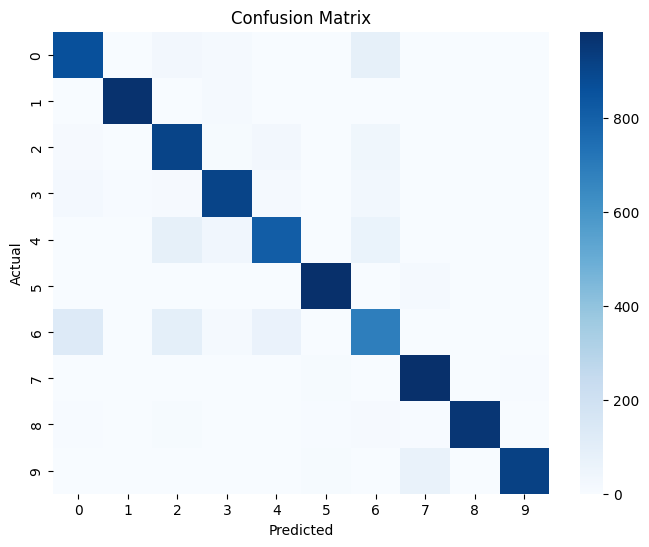


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.86      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.91      0.85      1000
       Dress       0.90      0.91      0.91      1000
        Coat       0.87      0.81      0.84      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.75      0.69      0.72      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.99      0.96      0.98      1000
  Ankle boot       0.99      0.92      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



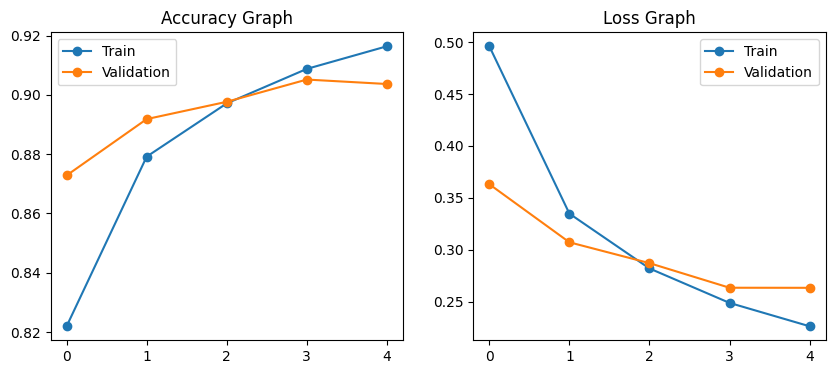

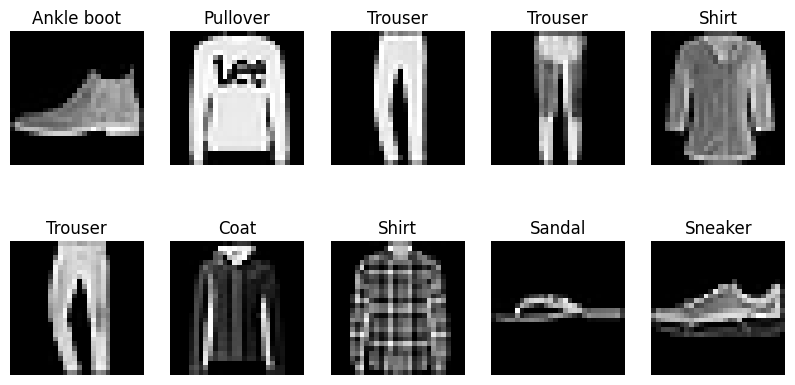

In [ ]:
# ==========================================
# Assignment 8: CNN on Fashion MNIST
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Dataset Loaded Successfully")

# Class labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ------------------------------------------
# 2. Build CNN Model
# ------------------------------------------
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------
# 3. Train Model
# ------------------------------------------
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ------------------------------------------
# 4. Evaluate Model
# ------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("\nTest Accuracy:", test_acc)

# ------------------------------------------
# 5. Predictions
# ------------------------------------------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------------------------------
# 7. Classification Report
# ------------------------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# ------------------------------------------
# 8. Accuracy & Loss Graphs
# ------------------------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o', label='Train')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation')
plt.title("Accuracy Graph")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o', label='Train')
plt.plot(history.history['val_loss'], marker='o', label='Validation')
plt.title("Loss Graph")
plt.legend()

plt.show()

# ------------------------------------------
# 9. Show Predictions
# ------------------------------------------
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"{class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()